# 🌡️ Tomorrow Temperature Forecast using Machine Learning

## Project Overview

This project predicts the maximum temperature of the next day using historical weather data collected from Open-Meteo.

Three regression models were developed and compared:

- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

The models were evaluated using:
- MAE
- RMSE
- R² Score

Finally, the best-performing model was selected based on predictive accuracy.

## Import Libraries

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import joblib

## Load Dataset

In [26]:
meteo = pd.read_csv("meteo2.csv", index_col='time',  parse_dates = True )

## Data Preprocessing

In [27]:

meteo["max_lag_1"] = meteo["temperature_2m_max (°C)"].shift(1)
meteo["max_lag_2"] = meteo["temperature_2m_max (°C)"].shift(2)
meteo["max_lag_7"] = meteo["temperature_2m_max (°C)"].shift(7)
meteo["max_lag_14"] = meteo["temperature_2m_max (°C)"].shift(14)


meteo["max_roll7"] = meteo["temperature_2m_max (°C)"].rolling(7).mean()

meteo = meteo.dropna()

## Feature Engineering

In [28]:
meteo.index = pd.to_datetime(meteo.index)


meteo["month"] = meteo.index.month
meteo["dayofyear"] = meteo.index.dayofyear


features = [
    "precipitation_sum (mm)",
    "temperature_2m_min (°C)",
    "relative_humidity_2m_mean (%)",
    "wind_speed_10m_max (km/h)",
    "max_lag_1", "max_lag_2", "max_lag_7", "max_lag_14",
    "max_roll7",
    "month", "dayofyear"
]


X = meteo[features]
y = meteo["temperature_2m_max (°C)"]

## Train/Test Split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, shuffle=False
)


## XGBoost

In [30]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="auto"
)

In [31]:
model.fit(X_train, y_train)
print("Model ready.")

Model ready.


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred)
rmse_xgb = mean_squared_error(y_test, y_pred) ** 0.5
r2_xgb = r2_score(y_test, y_pred_rf)

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("r2:", r2_xgb)

MAE: 1.4167201024636453
RMSE: 1.8159501992175808
r2: 0.9487435348654145


## Random Forest

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print(f"MAE  : {mae_rf:.3f}")
print(f"RMSE : {rmse_rf:.3f}")
print(f"R²   : {r2_rf:.3f}")

Random Forest Results
MAE  : 1.482
RMSE : 1.898
R²   : 0.949


## Linear Regression

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print(f"MAE  : {mae_lr:.3f}")
print(f"RMSE : {rmse_lr:.3f}")
print(f"R²   : {r2_lr:.3f}")

Linear Regression Results
MAE  : 1.658
RMSE : 2.139
R²   : 0.935


## Model Comparison

In [41]:
results = results.sort_values(by="RMSE").reset_index(drop=True)

results.style.format({
    "MAE": "{:.3f}",
    "RMSE": "{:.3f}",
    "R²": "{:.3f}"
}).highlight_min(subset=["MAE", "RMSE"], color="lightgreen") \
  .highlight_max(subset=["R²"], color="lightgreen")

,Model,MAE,RMSE,R²
0,XGBoost,1.417,1.816,0.949
1,Random Forest,1.482,1.898,0.949
2,Linear Regression,1.658,2.139,0.935


## Visualizations

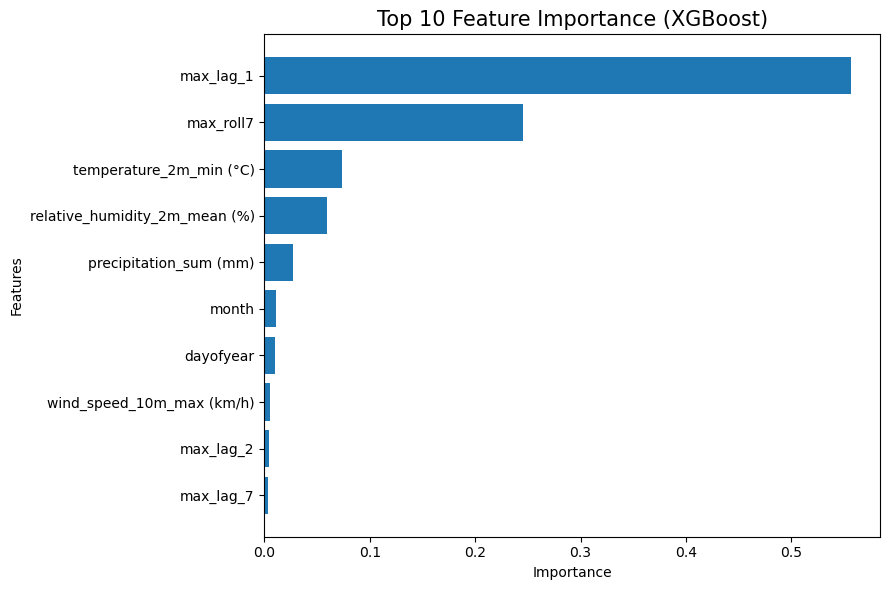

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(9,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance (XGBoost)", fontsize=15)
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

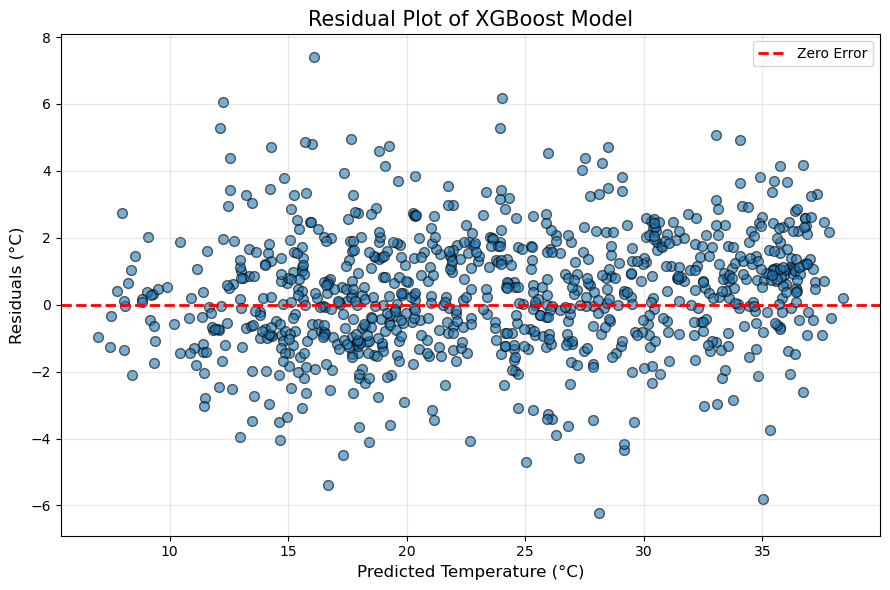

In [43]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(9,6))

plt.scatter(
    y_pred,
    residuals,
    s=50,
    alpha=0.6,
    edgecolors='black'
)

plt.axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Zero Error'
)

plt.xlabel("Predicted Temperature (°C)", fontsize=12)
plt.ylabel("Residuals (°C)", fontsize=12)
plt.title("Residual Plot of XGBoost Model", fontsize=15)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

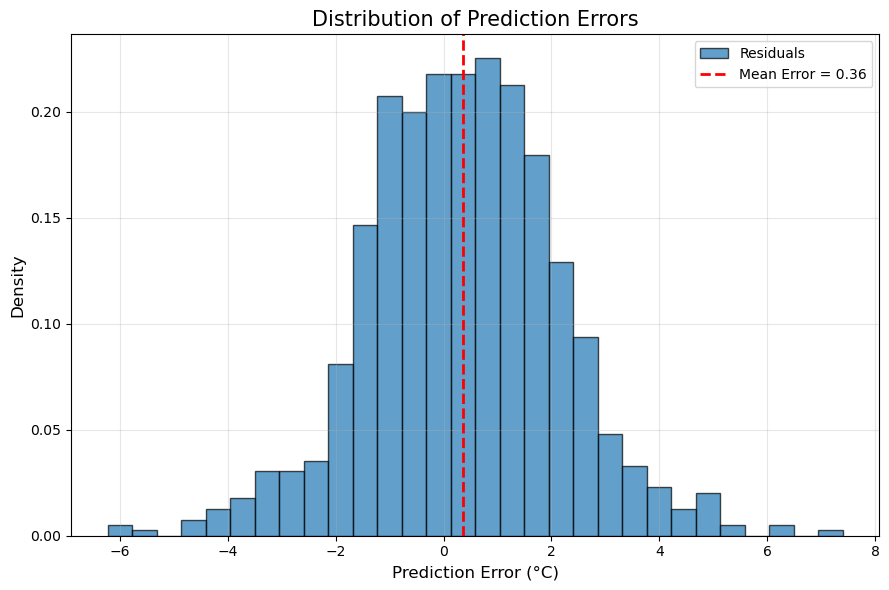

In [44]:
import matplotlib.pyplot as plt
import numpy as np

errors = y_test - y_pred

plt.figure(figsize=(9,6))

plt.hist(
    errors,
    bins=30,
    density=True,
    edgecolor='black',
    alpha=0.7,
    label='Residuals'
)

plt.axvline(
    np.mean(errors),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean Error = {np.mean(errors):.2f}'
)

plt.xlabel("Prediction Error (°C)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Distribution of Prediction Errors", fontsize=15)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Save Model

In [45]:
import joblib
joblib.dump(model, "xgb_temp_model.pkl")

['xgb_temp_model.pkl']

In [35]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta

# ===== 1. Setting up the Open-Meteo link for the city of Azrou =====
# Azrou coordinates (Approximate)
latitude = 33.4200
longitude = -5.2100

# Date Range: Last two years
end_date = datetime.today()
start_date = end_date - timedelta(days=30)

url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={latitude}&longitude={longitude}"
    f"&start_date={start_date.strftime('%Y-%m-%d')}&end_date={end_date.strftime('%Y-%m-%d')}"
    f"&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,relative_humidity_2m_mean,"
    f"wind_speed_10m_max&timezone=GMT"
)


# ===== 2. Fetching data from the Internet =====
response = requests.get(url)
data = response.json()


# ===== 3. Converting Data to a DataFrame =====
df = pd.DataFrame(data['daily'])
df['date'] = pd.to_datetime(df['time'])
df = df.sort_values('date').reset_index(drop=True)

# ===== 4. Creating lag features =====
lags = [1, 2, 7, 14]
for lag in lags:
    df[f'temp_lag_{lag}'] = df['temperature_2m_max'].shift(lag)


# ===== 5. Creating a rolling feature =====
df['temp_roll7'] = df['temperature_2m_max'].rolling(7).mean().shift(1)


# ===== 6. Time Features =====
df['month'] = df['date'].dt.month
df['dayofyear'] = df['date'].dt.dayofyear


# ===== 7. Reordering Columns =====
columns = ['precipitation_sum', 'temperature_2m_max', 'temperature_2m_min',
           'relative_humidity_2m_mean', 'wind_speed_10m_max',
           'temp_lag_1', 'temp_lag_2', 'temp_lag_7', 'temp_lag_14',
           'temp_roll7', 'month', 'dayofyear']

df_final = df[columns]


# ===== 8. Remove any rows containing NaN =====
df_final = df_final.dropna().reset_index(drop=True)


df_final.to_csv("azrou_weather_features.csv", index=False)


last_row = df_final.iloc[-1]

X_next = pd.DataFrame([{
    "precipitation_sum (mm)": last_row["precipitation_sum"],
    "temperature_2m_min (°C)": last_row["temperature_2m_min"],
    "relative_humidity_2m_mean (%)": last_row["relative_humidity_2m_mean"],
    "wind_speed_10m_max (km/h)": last_row["wind_speed_10m_max"],

   # lags due to max heat
    "max_lag_1": df_final["temperature_2m_max"].iloc[-1],
    "max_lag_2": df_final["temperature_2m_max"].iloc[-2],
    "max_lag_7": df_final["temperature_2m_max"].iloc[-7],
    "max_lag_14": df_final["temperature_2m_max"].iloc[-14],
    "max_roll7": df_final["temperature_2m_max"].iloc[-7:].mean(),

    "month": last_row["month"],
    "dayofyear": last_row["dayofyear"] + 1
}])

next_max_temp = model.predict(X_next)[0]
print("Forecasted maximum temperature for tomorrow:", next_max_temp)

Forecasted maximum temperature for tomorrow: 35.26501
